# Cosine synthetic example: linear encoding and Information Imbalance

This notebook treats $x$ as the **model representation** and $y$ as the
**neural representation**. The extra direction lives in $y$, not in $x$:

$$x\sim\mathcal U(0, x_{\max}),\qquad y=[\cos(x),\ s\,\varepsilon],\qquad \varepsilon\sim\mathcal N(0,1),$$

with $x_{\max}=5>\pi$, so that $\cos(x)$ folds, and noise scale $s=1$.

It:

1. generates the 1-D latent $x$ and the 2-D $y$ above;
2. fits the static projections $y\rightarrow\hat{x}$ and
   $x\rightarrow\hat{y}$;
3. computes $R^2$ for both target representations;
4. computes Information Imbalance between $\hat{x}$ and $\hat{y}$; and
5. repeats the reciprocal OLS and II analysis after replacing the non-zero
   singular values of each fitted map with one ($\Sigma_{01}$ normalization).

**The point: linear encoding and the normalized II pick opposite directions.**
Lower II means the source is more informative about the target; the summary
barplot shows $1-\mathrm{II}$ so that, as for $R^2$, higher is better.

| | $x\rightarrow y$ | $y\rightarrow x$ | favours |
|---|---|---|---|
| pooled $R^2$, original spaces | 0.13 | **0.41** | $y\rightarrow x$ |
| II, original spaces | 0.70 | **0.45** | $y\rightarrow x$ |
| II, $\Sigma_{01}$ normalized | **0.11** | 0.50 | $x\rightarrow y$ |

- **Pooled $R^2$ favours $y\rightarrow x$, only because of $y_2$.** The linear
  fit between $x$ and $y_1=\cos(x)$ is symmetric: with one input and one
  output, $R^2$ is the squared correlation, about 0.41 in both directions.
  $x\rightarrow y$ must also predict $y_2$, which is independent of $x$
  ($R^2\approx0$), and pooling over the two outputs pulls its score down.
- **II on the original spaces agrees with $R^2$**, for a related reason: with
  $s=1$ the noise axis $y_2$ dominates Euclidean distances in $y$, so
  neighbours in $x$ are scattered in $y$. (With a smaller $s$, around 0.2, the
  original II already favours $x\rightarrow y$.)
- **II after the $\Sigma_{01}$ normalization favours $x\rightarrow y$.** The
  reciprocal maps discard almost all of $y_2$, leaving $\widetilde{x}\propto x$
  and $\widetilde{y}$ mostly $\cos(x)$. Nearest neighbours in $x$ stay
  neighbours in $\cos(x)$, but past $\pi$ the cosine folds, so neighbours in
  $\cos(x)$ can come from opposite sides of the fold and lie far apart in $x$.
  After the normalization both spaces are rank one, so pooled $R^2$ becomes
  symmetric (0.41 both ways).

The projections are in-sample. Set `use_cv=True` to assemble out-of-fold
predictions with the configured cross-validation scheme.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    run_asymmetry_pipeline,
    summarize_asymmetry_pipeline,
)
from II_analyses.static_encoding import (
    compute_static_prediction_II,
    fit_static_projection,
)
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.general_utils.utils import get_triu_perms
from useful_stuff.general_utils.II import InformationImbalance

In [2]:
@dataclass
class Cfg:
    # Synthetic relation.
    n_samples: int = 1000
    x_min: float = 0
    # Past pi, cos(x) folds, so II becomes directional; below 2*pi it keeps a
    # net linear trend, so linear R2 stays informative.
    x_max: float = 5.0
    noise_std: float = 0  # latent noise on x; kept at 0
    # Std of the independent noise axis y_2. Larger values widen the R2 gap
    # but, above ~0.3, make II on the original spaces flip towards y -> x too.
    # II after the Sigma normalization is essentially unaffected.
    y_noise_scale: float = 1
    random_seed: int = 0

    # Bidirectional static regression.
    regression_type: str = "lr"
    use_cv: bool = False
    cv_type: str = "kf"
    n_splits: int = 5
    shuffle: bool = True
    singular_value_rtol: float | None = None

    # Information Imbalance.
    x_RDM_metric: str = "euclidean"
    y_RDM_metric: str = "euclidean"
    k: int = 1
# EOC


cfg = Cfg()
cfg

Cfg(n_samples=1000, x_min=0, x_max=5.0, noise_std=0, y_noise_scale=1, random_seed=0, regression_type='lr', use_cv=False, cv_type='kf', n_splits=5, shuffle=True, singular_value_rtol=None, x_RDM_metric='euclidean', y_RDM_metric='euclidean', k=1)

## Generate $x$ and $y$

The arrays follow the project convention `(features, samples)`. Here $x$ has
**one** feature (the latent), $y$ has **two** features
($\cos(x)$ plus an independent Gaussian-noise coordinate), and both share the
same observations.

In [3]:
"""
y_func
Build the 2-D y representation from the 1-D latent x.

INPUT:
    - x: np.ndarray -> one-dimensional latent observations
    - rng: np.random.Generator -> seeded random-number generator
    - noise_scale: float -> standard deviation of the independent y noise axis

OUTPUT:
    - y: np.ndarray -> shape (2, samples): [cos(x), independent Gaussian noise]
"""
def y_func(x, rng, noise_scale):
    y_cos = np.cos(x)  # nonlinear, non-monotone image of the latent
    y_noise = rng.normal(0, noise_scale, size=len(x))  # axis independent of x
    return np.vstack((y_cos, y_noise))
# EOF


rng = np.random.default_rng(cfg.random_seed)
latent_u = rng.uniform(cfg.x_min, cfg.x_max, size=cfg.n_samples)
x_values = latent_u + rng.normal(0, cfg.noise_std, size=cfg.n_samples)

# x is the single latent (1 feature); y is its cosine image plus one noise axis.
x = x_values[np.newaxis, :]
y = y_func(x_values, rng=rng, noise_scale=cfg.y_noise_scale)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (1, 1000)
y shape: (2, 1000)


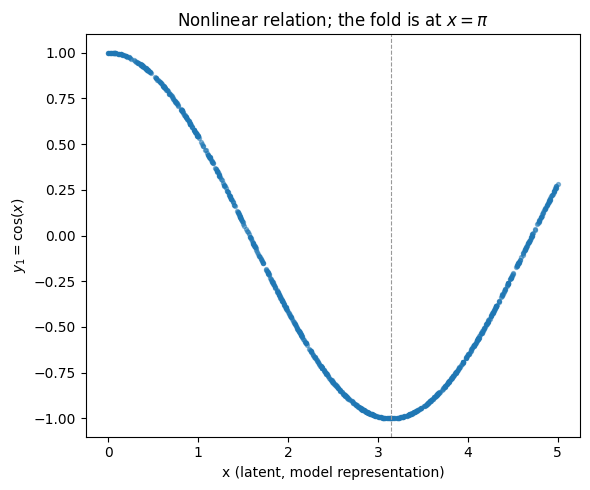

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x[0], y[0], s=8, alpha=0.5)
ax.axvline(np.pi, color="0.6", linewidth=0.8, linestyle="--")  # where cos folds
ax.set_xlabel("x (latent, model representation)")
ax.set_ylabel(r"$y_1 = \cos(x)$")
ax.set_title(r"Nonlinear relation; the fold is at $x=\pi$")
fig.tight_layout()

## Fit the two static linear projections

`predicted_x` is the $y\rightarrow x$ prediction and `predicted_y` is the
$x\rightarrow y$ prediction. When CV is enabled, both directions use identical
fold assignments and all reported predictions are out of fold.

In [5]:
if cfg.regression_type not in {"lr", "ridge", "lasso", "en"}:
    raise ValueError(f"Unsupported regression_type: {cfg.regression_type}")
# end if cfg.regression_type not in supported types
if cfg.use_cv and cfg.cv_type not in {"loo", "kf"}:
    raise ValueError("Use 'loo' or 'kf' when use_cv=True.")
# end if cfg.use_cv and cfg.cv_type not in supported types

active_cv_type = cfg.cv_type if cfg.use_cv else "same"
y_to_x_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)
x_to_y_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)

# Reset the seed before each direction so CV uses the same folds.
np.random.seed(cfg.random_seed)
predicted_x, x_r2 = fit_static_projection(
    y,
    x,
    y_to_x_encoding,
    use_cv=cfg.use_cv,
)

np.random.seed(cfg.random_seed)
predicted_y, y_r2 = fit_static_projection(
    x,
    y,
    x_to_y_encoding,
    use_cv=cfg.use_cv,
)

Encoding mode: in-sample
y -> x: R²=0.4088, prediction shape=(1, 1000)
x -> y: R²=0.2045, prediction shape=(2, 1000)
y -> x weight shape: (1, 2)
x -> y weight shape: (2, 1)


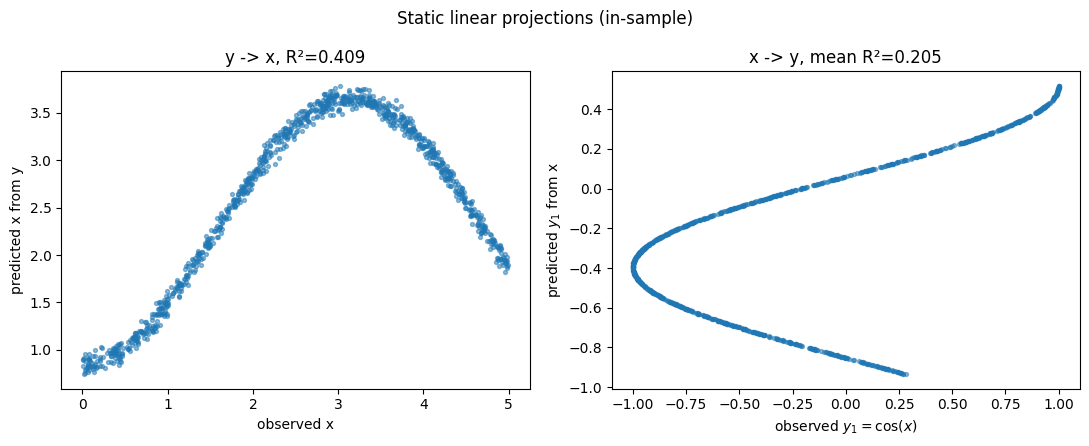

In [6]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(f"y -> x: R²={np.nanmean(x_r2):.4f}, prediction shape={predicted_x.shape}")
print(f"x -> y: R²={np.nanmean(y_r2):.4f}, prediction shape={predicted_y.shape}")
print(f"y -> x weight shape: {y_to_x_encoding.get_weights().shape}")
print(f"x -> y weight shape: {x_to_y_encoding.get_weights().shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x[0], predicted_x[0], s=8, alpha=0.5)
axes[0].set_xlabel("observed x")
axes[0].set_ylabel("predicted x from y")
axes[0].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")

axes[1].scatter(y[0], predicted_y[0], s=8, alpha=0.5)
axes[1].set_xlabel(r"observed $y_1 = \cos(x)$")
axes[1].set_ylabel(r"predicted $y_1$ from x")
axes[1].set_title(f"x -> y, mean R²={np.nanmean(y_r2):.3f}")

fig.suptitle(f"Static linear projections ({encoding_mode})")
fig.tight_layout()

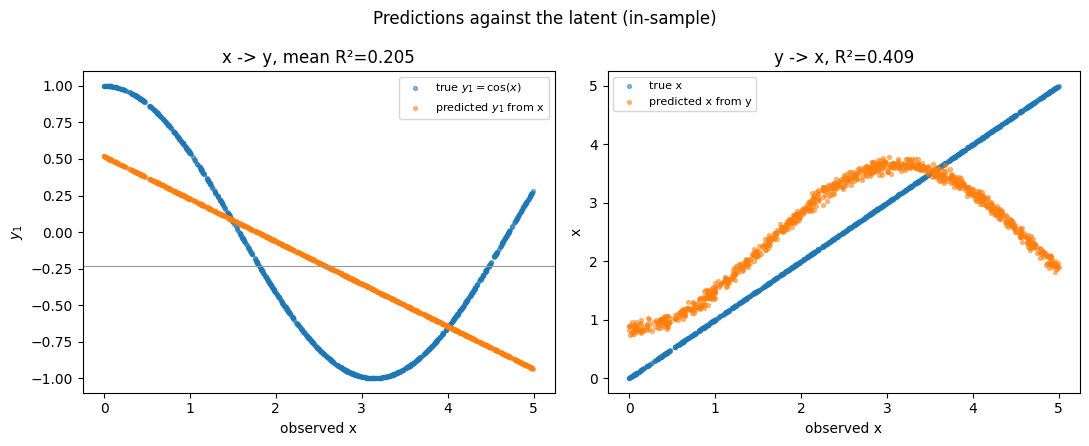

In [7]:
# Predictions against the latent axis, with the true target overlaid, to show
# what each direction can and cannot recover.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# x -> y_1: the linear fit is a straight line through the cosine curve.
axes[0].scatter(x[0], y[0], s=8, alpha=0.5, label=r"true $y_1=\cos(x)$")
axes[0].scatter(x[0], predicted_y[0], s=8, alpha=0.5, label=r"predicted $y_1$ from x")
axes[0].axhline(np.mean(y[0]), color="0.6", linewidth=0.8)
axes[0].set_xlabel("observed x")
axes[0].set_ylabel(r"$y_1$")
axes[0].set_title(f"x -> y, mean R²={np.nanmean(y_r2):.3f}")
axes[0].legend(fontsize=8)

# y -> x: the prediction is (almost) a linear function of cos(x), so points on
# the two sides of the fold get the same predicted x.
axes[1].scatter(x[0], x[0], s=8, alpha=0.5, label="true x")
axes[1].scatter(x[0], predicted_x[0], s=8, alpha=0.5, label="predicted x from y")
axes[1].set_xlabel("observed x")
axes[1].set_ylabel("x")
axes[1].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")
axes[1].legend(fontsize=8)

fig.suptitle(f"Predictions against the latent ({encoding_mode})")
fig.tight_layout()

In [8]:
print(np.var(x))
print(np.var(y))

2.024726913722139
0.6969610751901506


## Information Imbalance between the predicted spaces

The helper labels its first input as the neural space and its second input as
the model space. Here those inputs are `predicted_y` and `predicted_x`, so `A2B`
is predicted $y\rightarrow$ predicted $x$ and `B2A` is the reverse.

Note that `predicted_y` lives in $y$'s coordinates but is a linear function of
$x$ (it is $\propto x$), while `predicted_x` is a linear function of $y$
(mostly $\propto\cos(x)$). So "predicted $y\rightarrow$ predicted $x$" plays the
role of $x\rightarrow y$, and its value matches the $x\rightarrow y$ II in the
$\Sigma_{01}$-normalized table below.

In [9]:
_, predicted_y_to_x_II, predicted_x_to_y_II = compute_static_prediction_II(
    predicted_neural=predicted_y,
    predicted_model=predicted_x,
    neural_RDM_metric=cfg.y_RDM_metric,
    model_RDM_metric=cfg.x_RDM_metric,
    k=cfg.k,
)

print(f"predicted y -> predicted x: II={predicted_y_to_x_II:.6f}")
print(f"predicted x -> predicted y: II={predicted_x_to_y_II:.6f}")

predicted y -> predicted x: II=0.110434
predicted x -> predicted y: II=0.496420


In [10]:
residuals_x = x - predicted_x
residuals_y = y - predicted_y


In [11]:
space_names = ["x", "y", "predicted_x", "predicted_y", "residuals_x", "residuals_y"]
all_spaces = [x, y, predicted_x, predicted_y, residuals_x, residuals_y]
space_metrics = [
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
]

# Rows are source spaces and columns are target spaces.
ii_matrix = np.full((len(all_spaces), len(all_spaces)), np.nan)
space_index_pairs = get_triu_perms(list(range(len(all_spaces))))

for idx_A, idx_B in space_index_pairs:
    ii_obj = InformationImbalance(
        signal_RDM_metric=space_metrics[idx_A],
        model_RDM_metric=space_metrics[idx_B],
        k=cfg.k,
    )
    ii_obj.compute_both_RDMs(all_spaces[idx_A], all_spaces[idx_B])
    ii_obj.compute_both_distance_ranks()
    A_to_B_II, B_to_A_II = ii_obj.compute_both_II()

    # A2B is row A -> column B; B2A occupies the transposed position.
    ii_matrix[idx_A, idx_B] = A_to_B_II
    ii_matrix[idx_B, idx_A] = B_to_A_II
# end for idx_A, idx_B in space_index_pairs

ii_table = pd.DataFrame(ii_matrix, index=space_names, columns=space_names)
ii_table.index.name = "source"
ii_table.columns.name = "target"

# Each cell contains II(row source -> column target); self-pairs are blank.
ii_table.style.format(precision=3, na_rep="--").background_gradient(
    cmap="viridis",
    axis=None,
    vmin=0,
    vmax=1,
).set_caption("Directional Information Imbalance")


target,x,y,predicted_x,predicted_y,residuals_x,residuals_y
source,,,,,,
x,--,0.701,0.110,0.000,0.191,0.780
y,0.453,--,0.056,0.453,0.613,0.112
predicted_x,0.496,0.614,--,0.496,0.730,0.745
predicted_y,0.000,0.701,0.110,--,0.191,0.780
residuals_x,0.392,0.767,0.546,0.392,--,0.757
residuals_y,0.482,0.121,0.411,0.482,0.545,--


## SVD-normalize the reciprocal OLS maps

This repeats the full-data OLS analysis used in `gaussian_ols_svd_asymmetry`.
For each fitted coefficient matrix $B=U\Sigma V^\top$ (outputs by inputs),
the non-zero singular values are replaced with one:

$$B_{01}=U\Sigma_{01}V^\top, \qquad W_{01}=B_{01}^\top. $$

The row-wise transforms are $\widetilde{x}=x^\top W_{01}^{x\to y}$ and
$\widetilde{y}=y^\top W_{01}^{y\to x}$. Numerical null directions remain
zero, so the fitted rank is preserved while axis-specific regression gains
are removed. Because $x$ has one feature and $y$ has two, $\widetilde{x}$
has two collinear features and $\widetilde{y}$ has one. The $y\rightarrow x$
map only weights the noise axis through its chance in-sample correlation with
$x$, so $\widetilde{y}$ is mostly a rescaled $\cos(x)$ while $\widetilde{x}$ is a
rescaled $x$.

In [12]:
# The shared pipeline expects samples in rows, unlike this notebook's static spaces.
svd_pipeline = run_asymmetry_pipeline(
    source=x.T,
    target=y.T,
    source_metric=cfg.x_RDM_metric,
    target_metric=cfg.y_RDM_metric,
    k=cfg.k,
    relative_tolerance=cfg.singular_value_rtol,
)
svd_summary = summarize_asymmetry_pipeline(svd_pipeline, "x", "y")
display(svd_summary.style.format({"pooled R2": "{:.6f}", "II": "{:.6f}"}))

# Recover the matrices displayed in the Gaussian example.
svd_directions = (
    (
        "x -> y",
        svd_pipeline["original_fit"]["source_to_target"],
        svd_pipeline["source_svd"],
    ),
    (
        "y -> x",
        svd_pipeline["original_fit"]["target_to_source"],
        svd_pipeline["target_svd"],
    ),
)

for direction, encoding, svd_result in svd_directions:
    coefficient = np.atleast_2d(np.asarray(encoding.get_weights(), dtype=float))
    sigma_01 = np.diag(svd_result["active"].astype(float))
    row_weights = coefficient.T
    normalized_row_weights = svd_result["row_transform"]

    print(f"{direction}: rank={svd_result['rank']}")
    print("singular values:", np.round(svd_result["singular_values"], 6))
    print("Sigma_01:\n", sigma_01)
    print(f"W, shape {row_weights.shape}:\n", np.round(row_weights, 6))
    print(
        f"W_01, shape {normalized_row_weights.shape}:\n",
        np.round(normalized_row_weights, 6),
    )
    print()
# end for direction, encoding, svd_result

x_tilde = svd_pipeline["transformed_source"].T
y_tilde = svd_pipeline["transformed_target"].T
print(f"x_tilde shape: {x_tilde.shape}; y_tilde shape: {y_tilde.shape}")

# The rectangular transforms exchange the output dimensionalities of the maps.
assert x_tilde.shape == (y.shape[0], cfg.n_samples)
assert y_tilde.shape == (x.shape[0], cfg.n_samples)
assert svd_pipeline["source_svd"]["rank"] == np.linalg.matrix_rank(
    svd_pipeline["source_svd"]["row_transform"]
)
assert svd_pipeline["target_svd"]["rank"] == np.linalg.matrix_rank(
    svd_pipeline["target_svd"]["row_transform"]
)


,stage,direction,R2 per output,pooled R2,II
0,original,x -> y,"[0.407015, 0.002061]",0.125765,0.701434
1,original,y -> x,[0.408819],0.408819,0.453424
2,Sigma^-1 normalized,x -> y,[0.408819],0.408819,0.110434
3,Sigma^-1 normalized,y -> x,"[0.408819, 0.408819]",0.408819,0.496420


x -> y: rank=1
singular values: [0.292311]
Sigma_01:
 [[1.]]
W, shape (1, 2):
 [[-0.290643 -0.031184]]
W_01, shape (1, 2):
 [[-0.994293 -0.106682]]

y -> x: rank=1
singular values: [1.401331]
Sigma_01:
 [[1.]]
W, shape (2, 1):
 [[-1.399966]
 [-0.061835]]
W_01, shape (2, 1):
 [[-0.999026]
 [-0.044126]]

x_tilde shape: (2, 1000); y_tilde shape: (1, 1000)


### Geometry after singular-value binarization

Matched observations keep the same color in every panel. The first panel is the
original 2-D $y$ space, the middle panel shows the two transformed
representations against one another, and the last panel makes the rank-one
geometry of the two-dimensional $\widetilde{x}$ explicit.

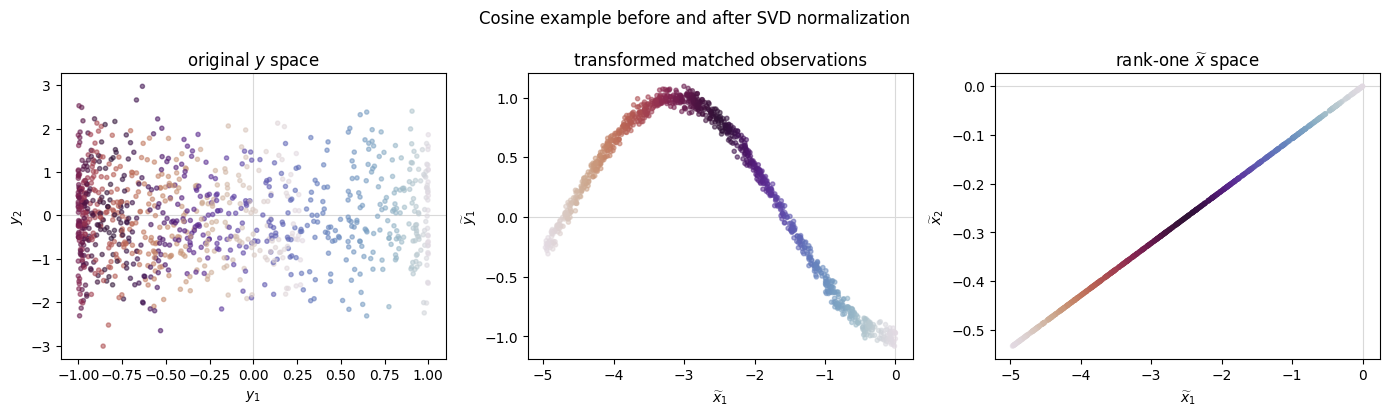

In [13]:
point_color = latent_u
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].scatter(
    y[0], y[1], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[0].set(
    xlabel=r"$y_1$", ylabel=r"$y_2$", title=r"original $y$ space"
)

axes[1].scatter(
    x_tilde[0], y_tilde[0], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[1].set(
    xlabel=r"$\widetilde{x}_1$",
    ylabel=r"$\widetilde{y}_1$",
    title="transformed matched observations",
)

axes[2].scatter(
    x_tilde[0], x_tilde[1], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[2].set(
    xlabel=r"$\widetilde{x}_1$",
    ylabel=r"$\widetilde{x}_2$",
    title=r"rank-one $\widetilde{x}$ space",
)

for ax in axes:
    ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)
# end for ax in axes

fig.suptitle("Cosine example before and after SVD normalization")
fig.tight_layout()

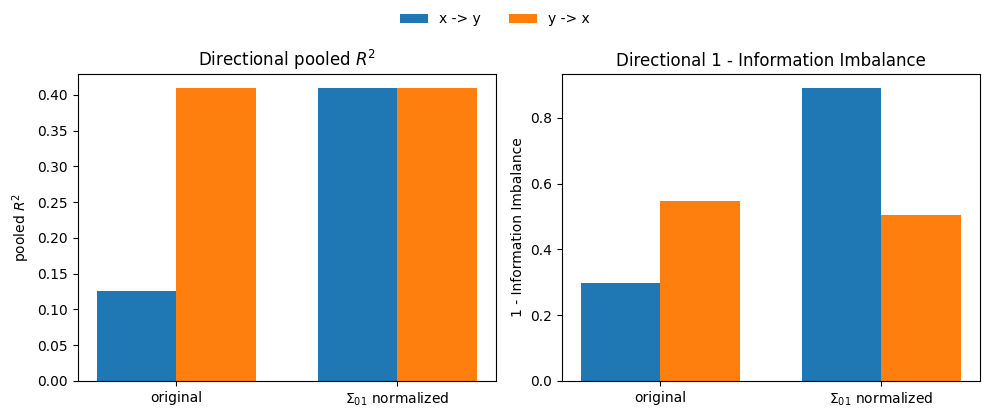

In [14]:
# Compare directional asymmetry before and after the reciprocal transforms.
# Groups on the x-axis are the two stages; within each group the two directions
# sit side by side. II is shown as 1 - II so both panels read "higher = more
# informative", which makes an R2 / II inversion visible as swapped bar heights.
stage_names = ["original", "Sigma^-1 normalized"]
stage_labels = ["original", r"$\Sigma_{01}$ normalized"]
direction_labels = ["x -> y", "y -> x"]
bar_positions = np.arange(len(stage_names))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, metric_name, ylabel in (
    (axes[0], "pooled R2", r"pooled $R^2$"),
    (axes[1], "II", "1 - Information Imbalance"),
):
    for direction_idx, direction in enumerate(direction_labels):
        # One value per stage for this direction, in stage_names order.
        direction_rows = svd_summary[svd_summary["direction"] == direction]
        values = direction_rows.set_index("stage").loc[stage_names, metric_name]
        if metric_name == "II":
            values = 1 - values
        # end if metric_name == "II"
        offset = (direction_idx - 0.5) * bar_width
        ax.bar(bar_positions + offset, values, width=bar_width, label=direction)
    # end for direction_idx, direction
    ax.set_xticks(bar_positions, stage_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Directional {ylabel}")
# end for ax, metric_name, ylabel

# One shared legend above the panels so it never covers the bars.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))

### The two projected spaces

$\widetilde{y}$ is one-dimensional, so it is drawn along a horizontal line.
$\widetilde{x}$ has two coordinates but rank one, so its observations lie on
a line in the two-dimensional output space. Colors identify matched samples:
along $\widetilde{x}$ the colors are ordered, along $\widetilde{y}$ the two
sides of the fold overlap.